In [1]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## Laboratorio_1.2
Hacer el analisis estadístico de las variables: Millas por galón (mpg) vs potencia (horsepower) in the dataset: millas_por_galón.csv. Contruya el fit de al $95$ C.L.  

In [2]:
#vamos a abrir el dataset de millas por galón desde el github del curso

url = "https://raw.githubusercontent.com/danielduque1/Fisica_Computacional_1/refs/heads/main/Sesiones/seaborn/millas_por_galon.csv"
df = pd.read_csv(url)

df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [3]:
# Creemos un dataframe con solo las columnas de millas por galón (mpg) y potencia (horsepower)

print(df.columns)
datos = df[["mpg","horsepower"]]

datos.head()

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model_year', 'origin', 'name'],
      dtype='object')


,mpg,horsepower
0,18.0,130.0
1,15.0,165.0
2,18.0,150.0
3,16.0,150.0
4,17.0,140.0


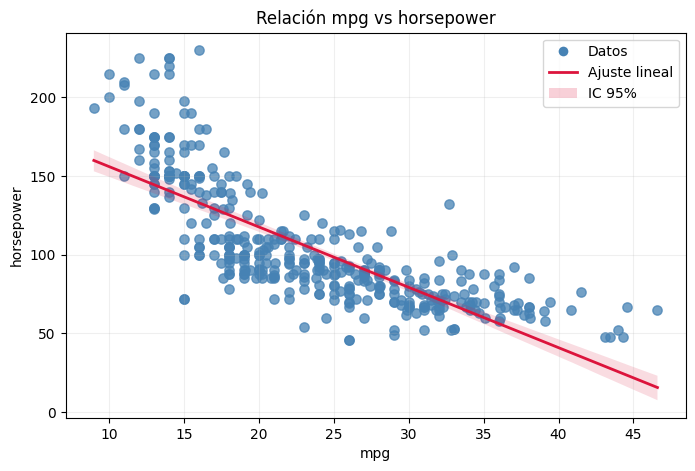

In [4]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

datos_fit = datos.dropna(subset=["mpg", "horsepower"])

plt.figure(figsize=(8, 5))

ax = sns.regplot(
    data=datos_fit,
    x="mpg",
    y="horsepower",
    ci=95,
    scatter_kws={"alpha": 0.75, "s": 45, "color": "steelblue"},
    line_kws={"color": "crimson", "lw": 2},
)

legend_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="steelblue", markersize=8, label="Datos"),
    Line2D([0], [0], color="crimson", lw=2, label="Ajuste lineal"),
    Patch(facecolor="crimson", alpha=0.2, edgecolor="none", label="IC 95%")
]
ax.legend(handles=legend_handles, loc="upper right")

plt.title("Relación mpg vs horsepower")
plt.xlabel("mpg")
plt.ylabel("horsepower")
plt.grid(alpha=0.2)
plt.show()

del grafico  se observa que los datos estan claramente correlacionados, aunque es notable que probablemente un ajuste lineal no sea el mas correcto

In [7]:
# Nuevo dataframe con logaritmo natural de ambas variables

datos_ln = np.log(datos_fit[["mpg", "horsepower"]])
datos_ln.columns = ["ln_mpg", "ln_horsepower"]

datos_ln.head()

,ln_mpg,ln_horsepower
0,2.890372,4.867534
1,2.708050,5.105945
2,2.890372,5.010635
3,2.772589,5.010635
4,2.833213,4.941642


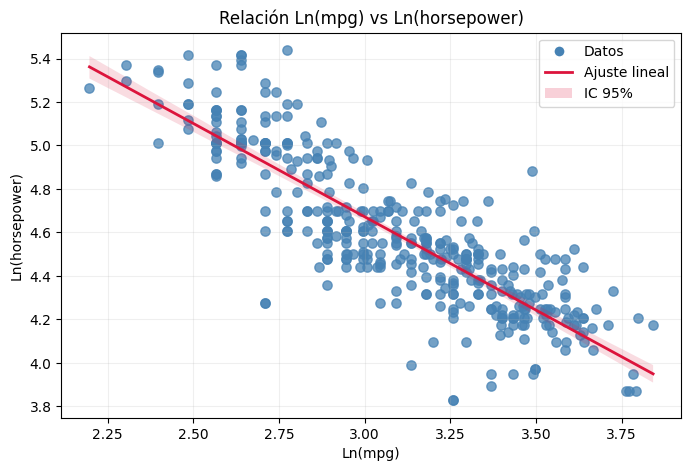

In [8]:
plt.figure(figsize=(8, 5))

ax = sns.regplot(
    data=datos_ln,
    x="ln_mpg",
    y="ln_horsepower",
    ci=95,
    scatter_kws={"alpha": 0.75, "s": 45, "color": "steelblue"},
    line_kws={"color": "crimson", "lw": 2},
)

legend_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="steelblue", markersize=8, label="Datos"),
    Line2D([0], [0], color="crimson", lw=2, label="Ajuste lineal"),
    Patch(facecolor="crimson", alpha=0.2, edgecolor="none", label="IC 95%")
]
ax.legend(handles=legend_handles, loc="upper right")

plt.title("Relación Ln(mpg) vs Ln(horsepower)")
plt.xlabel("Ln(mpg)")
plt.ylabel("Ln(horsepower)")
plt.grid(alpha=0.2)
plt.show()

Observe que al aplicar el logaritmo natural la distribución es ahora lineal, los datos seguian una relación exponencial entre ellos